## Load in the data

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy

(x_train, y_train), (x_test, y_test) = mnist.load_data()

## 2 Visuele analyse van cijfers

Doel: begrijpen waarom classificatie lastig is

**Vragen**

- Laat 5 willekeurige voorbeelden zien van éénzelfde cijfer (bijv. 3).

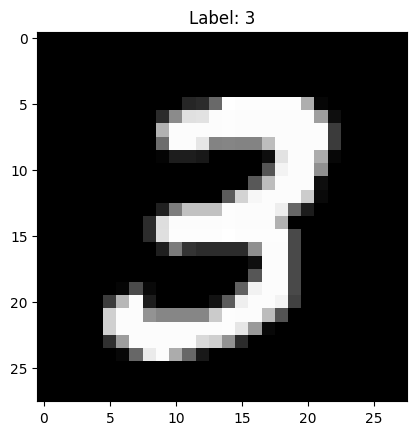 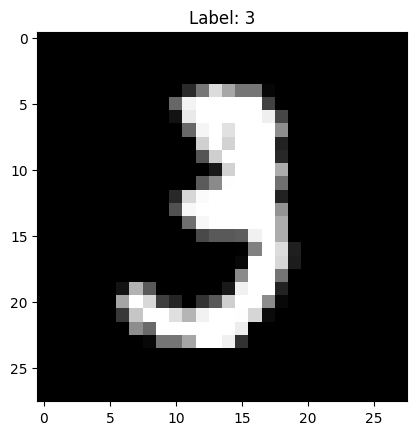 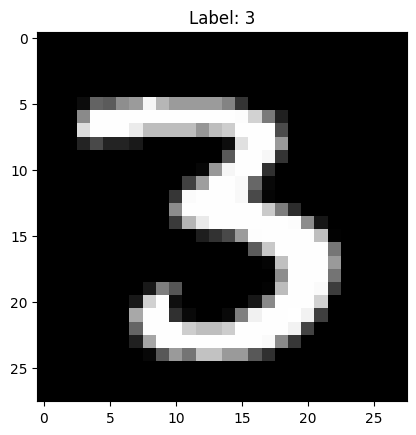 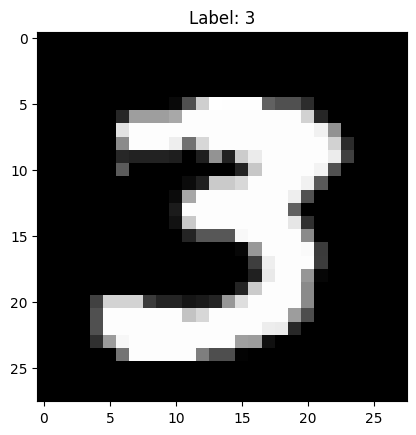 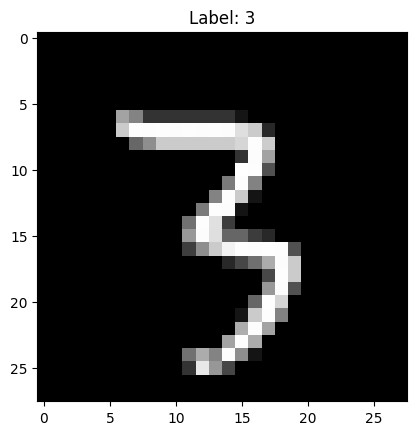

 
- Wat valt op?

Er is variatie tussen de cijfers in lijndikte schuinheid. Bepaalde delen zijn groter of kleiner gemaakt. In enkele gevallen gaan lijnen ook over elkaar heen waardoor de 3 op een 6 lijkt.

- Welke cijfers lijken visueel sterk op elkaar?
1 & 7
2 & 3
5 & 6
8 & 9
6 & 8

- Zijn sommige cijfers “slordiger” geschreven dan andere?

Er zijn veel afbeeldingen in de dataset waarvan vele die slordig zijn. Het is lastig om getallen in het algemeen slorig geschreven te noemen. Daarvoor is te veel data geleverd. mischien zijn de eerste 1000 4en wel relatief nettjes vergeleken met wat daarna komt.\
Over het algemeen kan gestelt worden dat er dermate veel beelden geleverd zijn dat iedere mogelijke vorm van verwarring wel ergens voor zal komen in de database.\ Of dat nu een 9 in die lijkt op een 8 of een 1 die heel schuin is en daardoor lijkt op een 2.

In [ ]:
import matplotlib.pyplot as plt

count = 0

for i, im in enumerate(x_train):
    if (y_train[i]):
        if count > 5:
            break
        plt.imshow(x_train[i], cmap="gray")
        plt.title(f"Label: {y_train[i]}")
        plt.show()
    count = count + 1


## 3. Pixelstatistieken (eerste stap richting features)

Doel: laten zien dat pixels data zijn, geen plaatjes

**Vragen**

Maak code om het volgende te bepalen:

Wat is de gemiddelde pixelwaarde van:

- alle afbeeldingen samen?

- één specifiek cijfer?

- Welke pixels zijn gemiddeld het “lichtst” of “donkerst”?

- Kun je het gemiddelde beeld van een cijfer maken?

Presentatie-output
- Eén “average digit” per groep
- Wat zien we eigenlijk volgens jou?

In [ ]:
# Methods
def ReportOnNumber(number: int = -1):
    used_images = list()
    if number == -1:
        used_images = x_train
    else:
        used_images = [x for i, x in enumerate(x_train) if y_train[i] == number] # only for specified number

    composite = CreateAverageImage(used_images)

    print("-----------------------------------------------------------------")
    print(f"report for: {number}")
    displayImage(composite, "average")
    displayImage(CreateAditiveImage(used_images), "additive")
    print(f"image is filled for:{CalculateAverageCoverage(composite)}%")


def CreateAverageImage(images: list) -> list:
    composite = numpy.zeros((28, 28))

    for image in images:
        numpy.add(image, composite, composite)

    numpy.divide(composite, len(images), composite)
    return composite


def CreateAditiveImage(images: list) -> list:
    """
    Layer all images over each other this will show what pixels have no coverage in any image
    """
    composite = numpy.zeros((28, 28))

    for image in images:
        numpy.maximum(image, composite, out=composite)

    return composite


def CalculateAverageCoverage(image) -> float:
    return numpy.average(image) / 255 * 100


def displayImage(image: list, label: str):
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.show()

In [ ]:
# Complete average
ReportOnNumber(-1)

In [ ]:
# Report indiviudal numbers
for number in range(10):
    ReportOnNumber(number)

# conclusie
Op basis van deze beelden kan vast worden gestelt dat er veel variatie is in te tekens. De additive beelden tonen vrijwel altijd een wit vlak, zonder gaten in het midden. Maar deze variate had nog extremer gekunt. Het is bijvoorbeeld uitgesloten dat er afbeeldingen zijn die zo veel mogelijk ruimte in beslag nemen. we hebben dus waarschijnlijk altijd te maken met dikke of dunne getekende afbeeldingen. End dus niet met een ontwerpt zoals op een wekker.